$$u_t = u_{xx}, \quad x \in (0, 1), \ t \in (0, 1), \quad u(x, 0) = \sin(\pi x), \quad u(0, t) = u(1, t) = 0.$$
$$u_{\text{exact}}(x, t) = e^{-\pi^2 t} \sin(\pi x).$$

Epoch [500/5000], Loss: 0.1245, Loss_IC: 0.0777, Loss_BC: 0.0394, Loss_PDE: 0.0074
Epoch [1000/5000], Loss: 0.0178, Loss_IC: 0.0094, Loss_BC: 0.0023, Loss_PDE: 0.0061
Epoch [1500/5000], Loss: 0.0016, Loss_IC: 0.0003, Loss_BC: 0.0002, Loss_PDE: 0.0011
Epoch [2000/5000], Loss: 0.0008, Loss_IC: 0.0000, Loss_BC: 0.0001, Loss_PDE: 0.0007
Epoch [2500/5000], Loss: 0.0004, Loss_IC: 0.0000, Loss_BC: 0.0001, Loss_PDE: 0.0003
Epoch [3000/5000], Loss: 0.0004, Loss_IC: 0.0000, Loss_BC: 0.0001, Loss_PDE: 0.0004
Epoch [3500/5000], Loss: 0.0002, Loss_IC: 0.0000, Loss_BC: 0.0000, Loss_PDE: 0.0002
Epoch [4000/5000], Loss: 0.0002, Loss_IC: 0.0000, Loss_BC: 0.0000, Loss_PDE: 0.0001
Epoch [4500/5000], Loss: 0.0002, Loss_IC: 0.0000, Loss_BC: 0.0000, Loss_PDE: 0.0001
Epoch [5000/5000], Loss: 0.0001, Loss_IC: 0.0000, Loss_BC: 0.0000, Loss_PDE: 0.0001

--- Adam 训练结束，进入 L-BFGS 微调阶段 ---
相对 L2 误差: 3.8830e-03


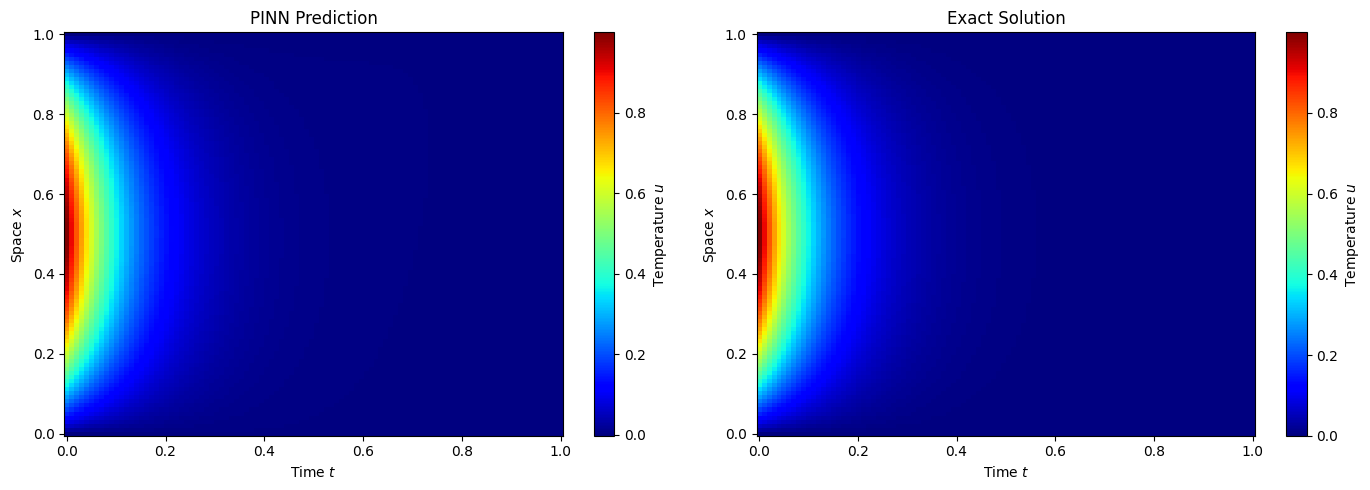

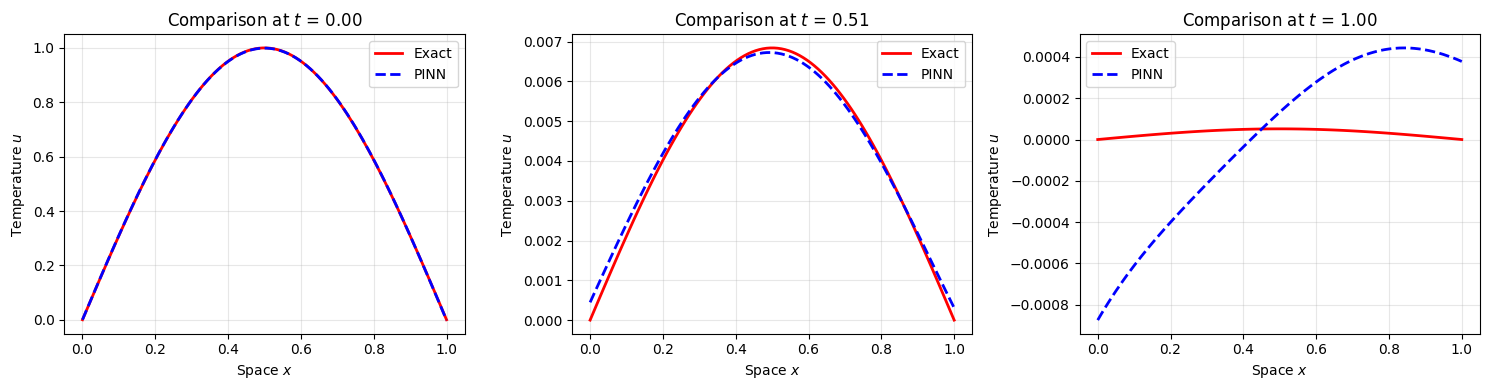

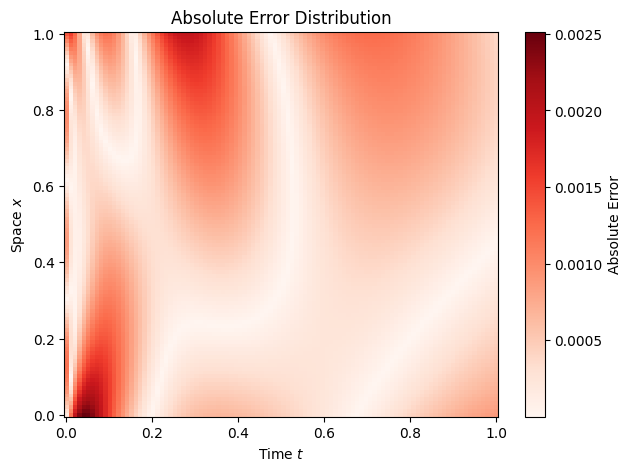

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
'''#1.准备dataset，随机抽点'''
#固定随机种子，不用torch.random.seed(),toech.seed(),这两个是同一个函数，都表示随机种子
torch.manual_seed(1306)
#给定物理边界
x_min,x_max=0.0,1.0
t_min,t_max=0.0,1.0
#设定采样数量（IC表示初始条件点，BC边界点，CP内部配点）
N_ic=100 #IC
N_bc=200 #BC
N_f=5000 #CP
#设定具体点
x_ic=x_min+(x_max-x_min)*torch.rand(N_ic,1)
t_ic=torch.zeros(N_ic,1)

x_bc_l=torch.zeros(N_bc//2,1)
t_bc_l=t_min+(t_max-t_min)*torch.rand(N_bc//2,1)

x_bc_r=torch.ones(N_bc//2,1)
t_bc_r=t_min+(t_max-t_min)*torch.rand(N_bc//2,1)

x_bc=torch.cat((x_bc_l,x_bc_r),dim=0)
t_bc=torch.cat((t_bc_l,t_bc_r),dim=0)

x_f=x_min+(x_max-x_min)*torch.rand(N_f,1)
t_f=t_min+(t_max-t_min)*torch.rand(N_f,1)

u_bc_label=torch.zeros(N_bc,1)
u_ic_label=torch.sin(torch.pi*x_ic)


'''2.定义网络架构'''
#我们采用一个简单的双层神经网络来拟合

class MyPinn(nn.Module):
    #__init__:声明组件
    def __init__(self):
        super().__init__()#继承nn.Module的必要功能

        self.layer1=nn.Linear(2,10)
        self.tanh=nn.Tanh()
        self.layer2=nn.Linear(10,20)
        self.layer3=nn.Linear(20,10)
        self.layer4=nn.Linear(10,1)
    #forward:定义前向传播,输入(x,t),这里定义数据流向
    def forward(self,x,t):
        input=torch.cat((x,t),dim=1)
        z1=self.layer1(input)
        a1=self.tanh(z1)
        z2=self.layer2(a1)
        a2=self.tanh(z2)
        z3=self.layer3(a2)
        a3=self.tanh(z3)
        z4=self.layer4(a3)
        return z4


#设备数据转移
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#实例化模型并转移到设备
x_ic=x_ic.to(device)
t_ic=t_ic.to(device)
u_ic_label=u_ic_label.to(device)
x_bc=x_bc.to(device)
t_bc=t_bc.to(device)
u_bc_label=u_bc_label.to(device)
x_f=x_f.to(device)
t_f=t_f.to(device)
model=MyPinn().to(device)
#开启自动求导追踪,因为在算loss的时候需要对x_f和t_f求导(注意必须放到to(device)之后)
x_f.requires_grad_(True)
t_f.requires_grad_(True)

'''3.定义损失函数和优化器'''
#定义损失函数，MSELoss适合回归问题
criterion=nn.MSELoss()
def calculate_loss(u,x,t,alpha=1):
    #求u_t
    u_t=torch.autograd.grad(
        u,t,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True
        )[0]
    #求u_xx,先求u_x
    u_x=torch.autograd.grad(
        u,x,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True
        )[0]
    #求u_xx
    u_xx=torch.autograd.grad(
        u_x,x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
        )[0]
    pde_residual= u_t-alpha*u_xx
    return criterion(pde_residual,torch.zeros_like(pde_residual))
#定义优化器
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)
alpha=1.0
'''4.训练模型'''
epochs=5000
for epoch in range(epochs):
    #(1)梯度清零
    optimizer.zero_grad()
    #(2)前向传播
    u_ic_predict=model(x_ic,t_ic)
    u_bc_predict=model(x_bc,t_bc)
    u_f_predict=model(x_f,t_f)
    #(3)计算损失
    #(3.1)数据驱动项：预测值和标签值的MSE
    loss_ic=criterion(u_ic_predict,u_ic_label)
    loss_bc=criterion(u_bc_predict,u_bc_label)
    #(3.2)物理驱动项：PDE残差的MSE
    loss_pde=calculate_loss(u_f_predict,x_f,t_f,alpha)
    #(3.3)总损失
    loss=loss_ic+loss_bc+loss_pde
    #(4)反向传播与参数更新
    #(4.1)反向传播
    loss.backward()
    #(4.2)优化器发力，参数更新
    optimizer.step()
    #(5)打印训练信息
    if (epoch+1)%500==0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Loss_IC: {loss_ic.item():.4f}, Loss_BC: {loss_bc.item():.4f}, Loss_PDE: {loss_pde.item():.4f}')
print("\n--- Adam 训练结束，进入 L-BFGS 微调阶段 ---")
#Adams 在训练初期快速下降，但后期可能会在局部最优附近震荡，难以进一步降低损失。
# L-BFGS 是一种拟牛顿方法，适合在损失函数较为平滑的情况下进行微调，可以帮助模型跳出局部最优，进一步降低损失。
# 1. 定义 L-BFGS 优化器
lbfgs_optimizer = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=5000)

# 2. 定义必须的 closure 闭包函数
def closure():
    lbfgs_optimizer.zero_grad()
    
    # 这里的逻辑和 Adam 循环里的一模一样
    u_pred_ic = model(x_ic, t_ic)
    u_pred_bc = model(x_bc, t_bc)
    u_pred_f  = model(x_f, t_f)
    
    loss_ic = criterion(u_pred_ic, u_ic_label)
    loss_bc = criterion(u_pred_bc, u_bc_label)
    loss_pde = calculate_loss(u_pred_f, x_f, t_f, alpha)
    
    total_loss = loss_ic + loss_bc + loss_pde
    total_loss.backward()
    
    return total_loss

# 3. 触发 L-BFGS 内部循环
lbfgs_optimizer.step(closure)
'''5.评估模型'''
#生成测试数据
# 生成 100x100 的密集均匀网格进行对比
x_test = torch.linspace(x_min, x_max, 100).to(device)
t_test = torch.linspace(t_min, t_max, 100).to(device)

# 生成坐标矩阵 (X, T)
X, T = torch.meshgrid(x_test, t_test, indexing='ij')

# 将网格拉平，准备送入网络预测
x_flat = X.reshape(-1, 1)
t_flat = T.reshape(-1, 1)
# 计算对应每一个网格点的真解
u_exact = torch.exp(- (torch.pi**2) * alpha * t_flat) * torch.sin(torch.pi * x_flat)

# 预测
with torch.no_grad():
    u_pred_flat = model(x_flat, t_flat)

# 误差分析 (L2 范数或均方误差)
error_l2 = torch.norm(u_exact - u_pred_flat, 2) / torch.norm(u_exact, 2)
print(f"相对 L2 误差: {error_l2.item():.4e}")

#准备数据绘图
U_pred = u_pred_flat.reshape(100, 100).cpu().numpy()
U_exact = u_exact.reshape(100, 100).cpu().numpy()
X_np = X.cpu().numpy()
T_np = T.cpu().numpy()

plt.figure(figsize=(14, 5))

# --- 子图 1: PINN 预测结果 ---
plt.subplot(1, 2, 1)

# 注意：T 对应横轴，X 对应纵轴
h1 = plt.pcolormesh(T.cpu().numpy(), X.cpu().numpy(), U_pred, cmap='jet', shading='auto')
plt.colorbar(h1, label='Temperature $u$')
plt.title('PINN Prediction')
plt.xlabel('Time $t$')
plt.ylabel('Space $x$')

# --- 子图 2:真解 ---
plt.subplot(1, 2, 2)
h2 = plt.pcolormesh(T.cpu().numpy(), X.cpu().numpy(), U_exact, cmap='jet', shading='auto')
plt.colorbar(h2, label='Temperature $u$')
plt.title('Exact Solution')
plt.xlabel('Time $t$')
plt.ylabel('Space $x$')

plt.tight_layout()
plt.show()

# --- 补充：特定时刻的 1D 切面对比 ---
# 选取三个代表性时刻：初始、中期、末期
t_indices = [0, 50, 99] 
plt.figure(figsize=(15, 4))

for i, idx in enumerate(t_indices):
    plt.subplot(1, 3, i + 1)
    # 提取特定时刻所有 x 点的预测和真解
    u_p = U_pred[:, idx]
    u_e = U_exact[:, idx]
    x_axis = x_test.cpu().numpy()
    
    plt.plot(x_axis, u_e, 'r-', linewidth=2, label='Exact')
    plt.plot(x_axis, u_p, 'b--', linewidth=2, label='PINN')
    plt.title(f'Comparison at $t$ = {t_test[idx].item():.2f}')
    plt.xlabel('Space $x$')
    plt.ylabel('Temperature $u$')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 补充：误差分布热力图 ---
plt.figure(figsize=(7, 5))
error_map = np.abs(U_pred - U_exact)
h3 = plt.pcolormesh(T.cpu().numpy(), X.cpu().numpy(), error_map, cmap='Reds', shading='auto')
plt.colorbar(h3, label='Absolute Error')
plt.title('Absolute Error Distribution')
plt.xlabel('Time $t$')
plt.ylabel('Space $x$')
plt.show()

In [3]:
import torch
torch.cuda.device_count()
torch.cuda.get_device_name(0)

'NVIDIA GeForce RTX 4060 Laptop GPU'